<a href="https://colab.research.google.com/github/mathiasdomician/classification-of-images/blob/main/partition_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import json
# import tensorflow as tf
# import numpy as np
# from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
# import numpy as np

# import shap

In [ ]:
!pip install shap

In [ ]:
!pip install tensorflow

In [ ]:
# # load pre-trained model and data
# model = ResNet50(weights="imagenet")
# X, y = shap.datasets.imagenet50()

In [ ]:
# # load the ImageNet class names
# url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
# with open(tf.keras.utils.get_file("imagenet_class_index.json", url)) as f:
#     class_names = [(v[1], v[0]) for v in json.load(f).values()]

In [ ]:
!pip install opencv-python

In [ ]:
# # Python function to get model output
# def f(x):
#     tmp = x.copy()
#     preprocess_input(tmp)
#     return model(tmp)

# # define a masker that is used to mask out partitions of the input image.
# masker = shap.maskers.Image("inpaint_telea", X[0].shape)

# # create an explainer with the corrected output_names
# explainer = shap.Explainer(f, masker, output_names=class_names)

# # Corrected code to get SHAP values one image at a time
# all_shap_values = []
# for i in range(1, 3):
#     image_to_explain = X[i:i+1]
#     single_prediction = f(image_to_explain)
#     top_k_indices = np.argsort(single_prediction, axis=1)[:, ::-1][0, :4]

#     shap_values = explainer(
#         image_to_explain,
#         max_evals=100,
#         batch_size=50,
#         outputs=top_k_indices
#     )
#     all_shap_values.append(shap_values)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
import shap
import json

# Load pre-trained model and data
model = ResNet50(weights="imagenet")
X, y = shap.datasets.imagenet50()

# Load the ImageNet class names
url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
with open(tf.keras.utils.get_file("imagenet_class_index.json", url)) as f:
    class_index = json.load(f)
    # Create a list of class names indexed by class id (string)
    class_names = [v[1] for k, v in sorted(class_index.items(), key=lambda item: int(item[0]))]

# python function to get model output; replace this function with your own model function.
def f(x):
    tmp = x.copy()
    preprocess_input(tmp)
    return model(tmp)


# define a masker that is used to mask out partitions of the input image.
masker = shap.maskers.Image("inpaint_telea", X[0].shape)

# create an explainer with model and image masker
explainer = shap.Explainer(f, masker, output_names=class_names)

# here we explain two images using 500 evaluations of the underlying model to estimate the SHAP values
shap_values = explainer(X[1:3], max_evals=100, batch_size=50, outputs=shap.Explanation.argsort.flip[:4])


  0%|          | 0/98 [00:00<?, ?it/s]


PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/98 [00:00<?, ?it/s]


PartitionExplainer explainer: 3it [00:40, 20.27s/it]


In [ ]:
shap_values.shape


(2, 224, 224, 3, 4)

In [ ]:
np.tile(np.array(shap_values.output_names), 2)

array([['American_egret', 'crane', 'little_blue_heron', 'flamingo',
        'American_egret', 'crane', 'little_blue_heron', 'flamingo'],
       ['speedboat', 'fountain', 'lifeboat', 'snowplow', 'speedboat',
        'fountain', 'lifeboat', 'snowplow']], dtype='<U30')

In [ ]:
np.array(shap_values.output_names).shape[0]

2

In [ ]:
shap_values.output_dims

(4,)

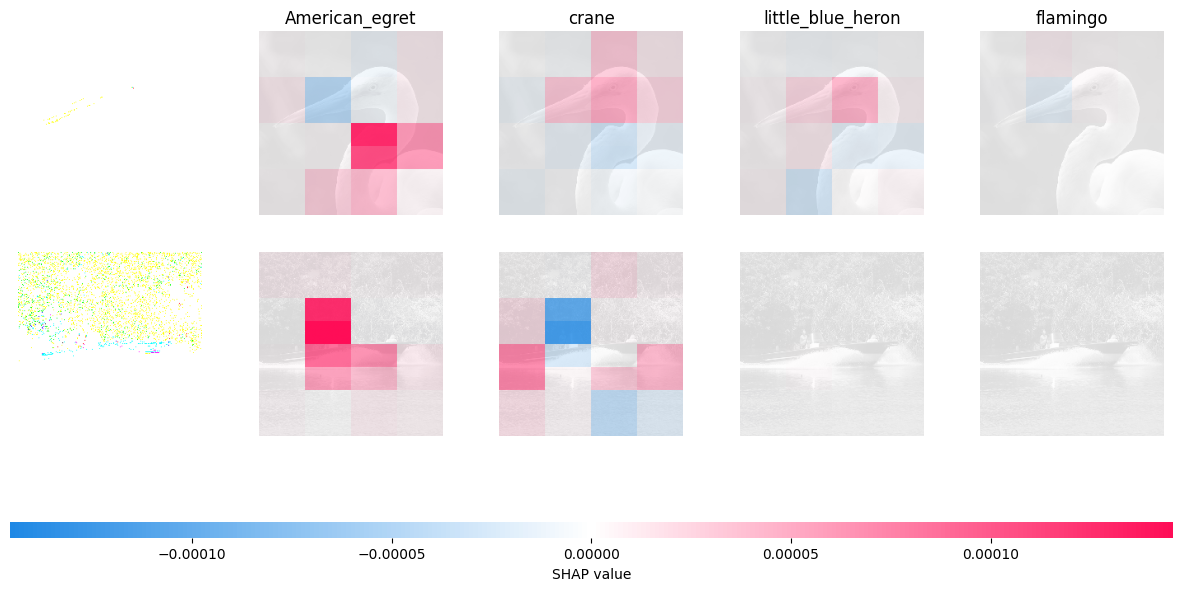

In [ ]:
# output with shap values
shap.image_plot(shap_values)

In [ ]:
shap_values[0].base_values.shape

(4,)

In [ ]:
shap_values[0].base_values

array([3.98262870e-04, 4.48953579e-05, 5.20894573e-05, 2.04478798e-04])

In [ ]:
shap_values.output_names

array([['American_egret', 'crane', 'little_blue_heron', 'flamingo'],
       ['speedboat', 'fountain', 'lifeboat', 'snowplow']], dtype='<U30')

In [ ]:
# python function to get model output; replace this function with your own model function.
def f(x):
    tmp = x.copy()
    preprocess_input(tmp)
    return model(tmp)


# define a masker that is used to mask out partitions of the input image.
masker_blur = shap.maskers.Image("blur(128,128)", X[0].shape)

# create an explainer with model and image masker
explainer_blur = shap.Explainer(f, masker_blur, output_names=class_names)

# here we explain two images using 500 evaluations of the underlying model to estimate the SHAP values
shap_values_fine = explainer_blur(X[1:3], max_evals=5000, batch_size=50, outputs=shap.Explanation.argsort.flip[:4])

  0%|          | 0/4998 [00:00<?, ?it/s]


PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/4998 [00:00<?, ?it/s]


PartitionExplainer explainer: 3it [27:06, 813.08s/it]


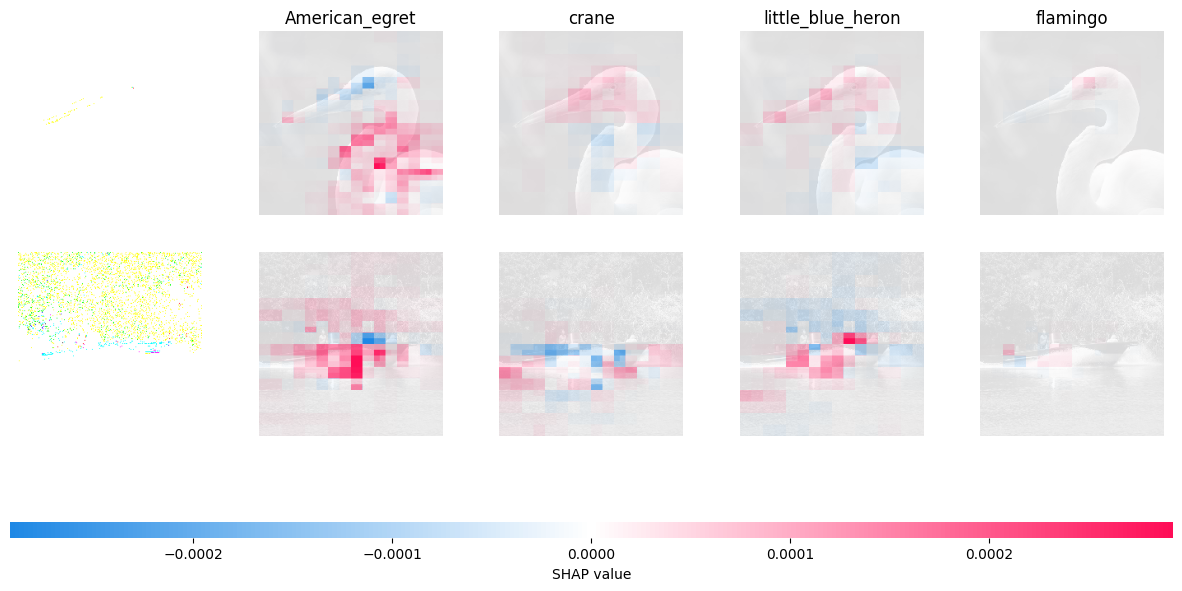

In [ ]:
# output with shap values
shap.image_plot(shap_values_fine)